# Chapter 36 Lab — Granger Causal Models (Python)

In this lab you will build the entire Granger-causality story on simulated data, where the ground truth is known. We follow a five-step arc:

1. **Simulate a VAR(1) system** with a genuine directed influence (region X drives region Y)
2. **Test Granger causality in both directions** with `statsmodels`, and see the true direction recovered
3. **Compute Geweke's directed influence measures** from restricted-vs-full model residuals
4. **Create the hemodynamic confound**: perfectly symmetric neural coupling, but different HRF latencies in the two regions — and watch Granger analysis confidently report a directed influence that does not exist
5. **Apply a deconvolution remedy**, removing each region's HRF before testing

Because we simulate everything, you can check each inference against the truth — the situation you never enjoy with real BOLD data, and exactly why this confound is so dangerous in practice.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `scipy`, `pandas`, `matplotlib`, and `statsmodels`, and all data are simulated — nothing to download. It accompanies the [chapter page](https://torwager.github.io/elements-of-fmri-tutorials/book/part6/ch36-granger-causal-models).

## 1. Simulate a VAR(1) system with a true directed influence

A first-order vector autoregressive (VAR(1)) model generates each new sample of the bivariate state $Z_t = (X_t, Y_t)^\top$ from the previous sample plus white noise:

::::{div}
:class: eq-tip
$$
Z_t = A\, Z_{t-1} + \epsilon_t, \qquad
A = \begin{bmatrix} 0.5 & 0 \\ 0.4 & 0.5 \end{bmatrix}
$$
:::{div}
:class: eq-tip-text
Zₜ — bivariate state (Xₜ, Yₜ) at time t · A — 2×2 coupling matrix (row = receiver, column = sender, at lag 1) · εₜ — unit-variance white noise
:::
::::
:::{div}
:class: eq-where
*where* $Z_t = (X_t, Y_t)^\top$ *is the bivariate state at time* $t$, $A$ *is the 2×2 coupling matrix (each row says how one region weights the previous sample of both regions), and* $\epsilon_t$ *is unit-variance white noise.*
:::

Read the coupling matrix row by row: $X_t$ depends only on its own past ($0.5\,X_{t-1}$), while $Y_t$ depends on its own past **and** on $X$'s past ($0.4\,X_{t-1} + 0.5\,Y_{t-1}$). So the ground truth is a one-way influence: **X drives Y at lag 1, with no reverse influence.** Think of each time step as one TR.

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

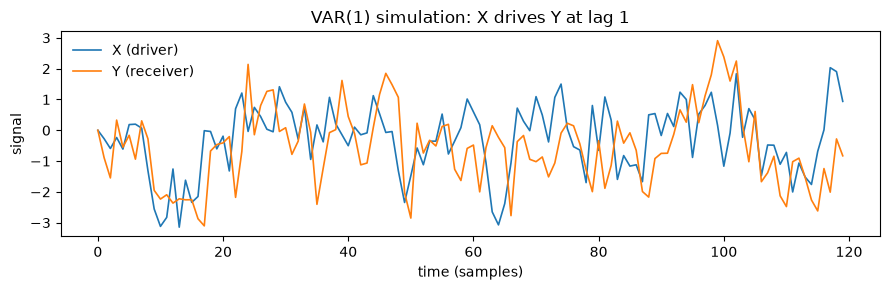

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io, contextlib
from scipy.stats import gamma
from scipy.linalg import toeplitz
from statsmodels.tsa.stattools import grangercausalitytests

rng = np.random.default_rng(7)            # seed, for reproducibility

n = 400                                   # time points (think: TRs)
A = np.array([[0.5, 0.0],                 # X(t) <- 0.5 X(t-1)
              [0.4, 0.5]])                # Y(t) <- 0.4 X(t-1) + 0.5 Y(t-1)

Z = np.zeros((n, 2))                      # columns: X, Y
eps = rng.standard_normal((n, 2))         # unit-variance white noise
for t in range(1, n):
    Z[t] = A @ Z[t - 1] + eps[t]
X, Y = Z[:, 0], Z[:, 1]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(X[:120], label="X (driver)", lw=1.2)
ax.plot(Y[:120], label="Y (receiver)", lw=1.2)
ax.set(xlabel="time (samples)", ylabel="signal",
       title="VAR(1) simulation: X drives Y at lag 1")
ax.legend(frameon=False)
plt.tight_layout()

## 2. Test Granger causality in both directions

A Granger test is a **nested-model comparison**. To ask "does X Granger cause Y?" we compare:

- **Restricted model:** $Y_t \sim Y_{t-1}, \dots, Y_{t-p}$ (Y's own history only)
- **Full model:** $Y_t \sim Y_{t-1}, \dots, Y_{t-p},\; X_{t-1}, \dots, X_{t-p}$

If the full model fits significantly better (an F-test on the reduction in residual sum of squares), X's history carries predictive information about Y beyond Y's own past — X Granger causes Y.

`statsmodels.tsa.stattools.grangercausalitytests` takes a 2-column array and tests whether the **second** column Granger causes the **first**. We wrap it in a small helper that runs one direction quietly and returns the F statistic and P value.

In [2]:
def granger_F(target, driver, lag=1):
    """F test of 'driver Granger-causes target' at the given lag order."""
    data = np.column_stack([target, driver])
    with contextlib.redirect_stdout(io.StringIO()):   # suppress verbose printout
        res = grangercausalitytests(data, maxlag=[lag])
    F, p, _, _ = res[lag][0]["ssr_ftest"]
    return F, p

results = pd.DataFrame(
    [granger_F(Y, X), granger_F(X, Y)],
    index=["X -> Y (true influence)", "Y -> X (no influence)"],
    columns=["F", "p"],
)
print(results.round(4))

                               F       p
X -> Y (true influence)  92.1349  0.0000
Y -> X (no influence)     0.0001  0.9917


The test recovers the truth emphatically: the F statistic for **X → Y** is enormous (P ≈ 10⁻¹⁹), while **Y → X** is essentially zero (P ≈ 0.99). Temporal precedence works perfectly here because the "neural" lag (1 sample) is visible at our sampling rate and — crucially — both series are measured *the same way*, with no differential measurement delay. Hold that thought for Section 4.

## 3. Geweke's directed influence measures

Geweke quantified directed influence with the ratio of innovation (residual) variances between the restricted and full models. For the influence of $X$ on $Y$:

::::{div}
:class: eq-tip
$$
F_{X \to Y} = \ln \frac{|\Sigma_2|}{|\Sigma_{yy}|}
$$
:::{div}
:class: eq-tip-text
F(X→Y) — directed influence of X on Y · Σ₂ — residual variance of Y predicted from its own past only · Σᵧᵧ — Y's residual variance in the joint model that also includes X's past
:::
::::
:::{div}
:class: eq-where
*where* $F_{X \to Y}$ *is the directed influence of* $X$ *on* $Y$, $\Sigma_2$ *is the residual (innovation) variance of* $Y$ *predicted from its own past only, and* $\Sigma_{yy}$ *is* $Y$'s *residual variance in the joint model that also includes* $X$'s *past.*
:::

If X's history helps, the joint model's residual variance shrinks and $F_{X \to Y} > 0$; if it doesn't help, the ratio is 1 and the measure is 0. In practice, the **difference** $F_{X \to Y} - F_{Y \to X}$ is often used to infer the net direction of influence — a convention that will matter below.

In [3]:
def geweke(target, driver, lag=1):
    """Geweke directed influence: ln(RSS_restricted / RSS_full)."""
    n = len(target)
    T = np.arange(lag, n)
    ones = np.ones(len(T))
    Xr = np.column_stack([target[T - j] for j in range(1, lag + 1)] + [ones])
    Xf = np.column_stack([target[T - j] for j in range(1, lag + 1)]
                         + [driver[T - j] for j in range(1, lag + 1)] + [ones])
    y = target[T]
    rss_r = np.sum((y - Xr @ np.linalg.lstsq(Xr, y, rcond=None)[0]) ** 2)
    rss_f = np.sum((y - Xf @ np.linalg.lstsq(Xf, y, rcond=None)[0]) ** 2)
    return np.log(rss_r / rss_f)

F_xy, F_yx = geweke(Y, X), geweke(X, Y)
print(f"F_(X->Y) = {F_xy:.4f}")
print(f"F_(Y->X) = {F_yx:.4f}")
print(f"difference (net influence, X->Y positive) = {F_xy - F_yx:.4f}")

F_(X->Y) = 0.2092
F_(Y->X) = 0.0000
difference (net influence, X->Y positive) = 0.2092


## 4. The hemodynamic confound: equal coupling, unequal HRF lags

fMRI does not measure neural activity — it measures BOLD, the neural signal blurred through a sluggish hemodynamic response that **varies across brain regions**. We now build the critical counterexample from the chapter:

- **Neural truth:** the two regions are coupled perfectly *symmetrically* — each influences the other with weight 0.3. There is no net directed influence.
- **Measurement:** region 1's HRF peaks early (~4 s) and region 2's peaks late (~7 s), a difference well within the range observed across real brain regions.

First, the two HRFs (double-gamma shapes, sampled at TR = 1 s):

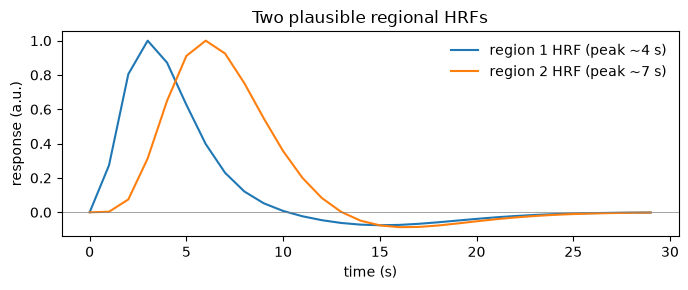

In [4]:
def hrf(t, peak, undershoot=16.0, ratio=6.0):
    """Double-gamma HRF, peak-normalized."""
    h = gamma.pdf(t, peak) - gamma.pdf(t, undershoot) / ratio
    return h / h.max()

t_hrf = np.arange(0, 30, 1.0)             # 30-s HRF grid at TR = 1 s
h_fast = hrf(t_hrf, 4.0)                  # region 1: early peak (~4 s)
h_slow = hrf(t_hrf, 7.0)                  # region 2: late peak (~7 s)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t_hrf, h_fast, label="region 1 HRF (peak ~4 s)")
ax.plot(t_hrf, h_slow, label="region 2 HRF (peak ~7 s)")
ax.axhline(0, color="gray", lw=0.5)
ax.set(xlabel="time (s)", ylabel="response (a.u.)",
       title="Two plausible regional HRFs")
ax.legend(frameon=False)
plt.tight_layout()

Now simulate the symmetric neural system, then pass each region's neural series through **its own** HRF (convolution) and add a little measurement noise to get the "observed" BOLD signals.

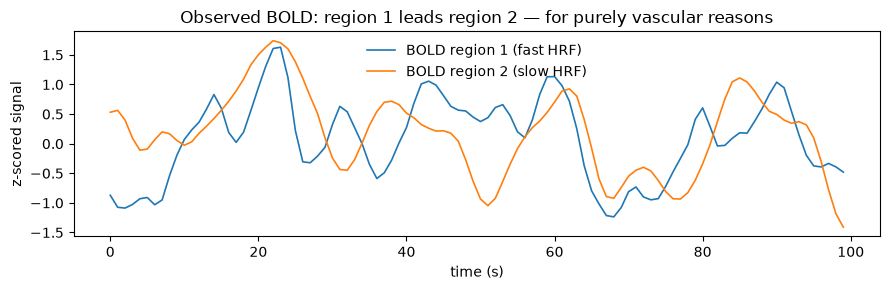

In [5]:
rng2 = np.random.default_rng(11)          # separate seed for the confound demo

n2, burn = 1000, 50                       # n2 = time points (TR = 1 s); burn = burn-in samples to discard
A_sym = np.array([[0.4, 0.3],             # region 1 <- itself + region 2, equally
                  [0.3, 0.4]])            # region 2 <- itself + region 1, equally
Zn = np.zeros((n2 + burn, 2))
e2 = rng2.standard_normal((n2 + burn, 2))
for t in range(1, n2 + burn):
    Zn[t] = A_sym @ Zn[t - 1] + e2[t]
Zn = Zn[burn:]                            # discard initial transient
neu1, neu2 = Zn[:, 0], Zn[:, 1]

sd_noise = 0.05                           # measurement-noise SD
bold1 = np.convolve(neu1, h_fast)[:n2] + sd_noise * rng2.standard_normal(n2)
bold2 = np.convolve(neu2, h_slow)[:n2] + sd_noise * rng2.standard_normal(n2)

zs = lambda v: (v - v.mean()) / v.std()
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(zs(bold1)[100:200], label="BOLD region 1 (fast HRF)", lw=1.2)
ax.plot(zs(bold2)[100:200], label="BOLD region 2 (slow HRF)", lw=1.2)
ax.set(xlabel="time (s)", ylabel="z-scored signal",
       title="Observed BOLD: region 1 leads region 2 — for purely vascular reasons")
ax.legend(frameon=False)
plt.tight_layout()

Region 1's BOLD trace visibly *leads* region 2's — not because its neurons fire first, but because its vasculature responds faster. Now run the Granger analysis at both levels: on the (unobservable) neural series, and on the (observable) BOLD series.

In [6]:
rows = {
    "neural: 1 -> 2": (geweke(neu2, neu1), *granger_F(neu2, neu1)),
    "neural: 2 -> 1": (geweke(neu1, neu2), *granger_F(neu1, neu2)),
    "BOLD:   1 -> 2": (geweke(bold2, bold1), *granger_F(bold2, bold1)),
    "BOLD:   2 -> 1": (geweke(bold1, bold2), *granger_F(bold1, bold2)),
}
table = pd.DataFrame(rows, index=["Geweke F", "F stat", "p"]).T
print(table.round(4))

print(f"\nNet influence (Geweke difference, 1->2 minus 2->1):")
print(f"  neural: {geweke(neu2, neu1) - geweke(neu1, neu2):+.4f}   (~0: symmetric, as designed)")
print(f"  BOLD:   {geweke(bold2, bold1) - geweke(bold1, bold2):+.4f}   (strongly positive: SPURIOUS)")

                Geweke F    F stat    p
neural: 1 -> 2    0.1037  108.8252  0.0
neural: 2 -> 1    0.1107  116.6137  0.0
BOLD:   1 -> 2    0.3681  443.2195  0.0
BOLD:   2 -> 1    0.1002  104.9623  0.0

Net influence (Geweke difference, 1->2 minus 2->1):
  neural: -0.0070   (~0: symmetric, as designed)
  BOLD:   +0.2679   (strongly positive: SPURIOUS)


At the **neural** level the two directed influences are nearly identical (~0.10 each) — the analysis correctly sees a symmetric system. At the **BOLD** level, the influence of the fast-HRF region on the slow-HRF region is inflated more than threefold relative to the reverse direction, and both directions are "highly significant". Anyone using the standard net-influence difference would confidently — and wrongly — conclude that region 1 drives region 2. Nothing about the neural dynamics changed; only the measurement did. This is the core of the critique of Granger causality mapping for fMRI: **temporal precedence in BOLD can be hemodynamic rather than neuronal.**

## 5. A deconvolution remedy

One proposed fix is to *deconvolve* each region's HRF from its BOLD series first — reconstructing a neural-like signal — and run the Granger analysis on that. Convolution is a linear operation, $b = H\,z$, where $H$ is a Toeplitz matrix built from the HRF, so we can invert it with regularized least squares:

::::{div}
:class: eq-tip
$$
\hat{z} = (H^\top H + \lambda I)^{-1} H^\top b
$$
:::{div}
:class: eq-tip-text
ẑ — reconstructed neural-like signal · H — Toeplitz convolution matrix built from the HRF · b — observed BOLD series · λ — ridge penalty (damps amplified noise) · I — identity matrix
:::
::::
:::{div}
:class: eq-where
*where* $\hat{z}$ *is the reconstructed neural-like signal,* $H$ *the Toeplitz convolution matrix built from the HRF,* $b$ *the observed BOLD series,* $\lambda$ *the ridge penalty that damps noise amplification, and* $I$ *the identity matrix.*
:::

The ridge penalty $\lambda$ is needed because deconvolution amplifies high-frequency noise. Here we grant ourselves a luxury real analyses never have: we use each region's **true** HRF. In practice the HRF must itself be estimated from the data, adding another layer of uncertainty.

In [7]:
def deconvolve(bold, h, lam=0.05):        # lam = ridge penalty; larger = smoother, more damped
    """Ridge-regularized deconvolution of an HRF from a time series."""
    n = len(bold)
    col = np.zeros(n)
    col[:len(h)] = h
    H = toeplitz(col, np.zeros(n))
    return np.linalg.solve(H.T @ H + lam * np.eye(n), H.T @ bold)

neu1_hat = deconvolve(bold1, h_fast)
neu2_hat = deconvolve(bold2, h_slow)

table2 = pd.DataFrame(
    {"1 -> 2": [geweke(neu2, neu1), geweke(bold2, bold1), geweke(neu2_hat, neu1_hat)],
     "2 -> 1": [geweke(neu1, neu2), geweke(bold1, bold2), geweke(neu1_hat, neu2_hat)]},
    index=["neural (truth)", "BOLD (confounded)", "deconvolved BOLD"],
)
table2["difference"] = table2["1 -> 2"] - table2["2 -> 1"]
print(table2.round(4))

                   1 -> 2  2 -> 1  difference
neural (truth)     0.1037  0.1107     -0.0070
BOLD (confounded)  0.3681  0.1002      0.2679
deconvolved BOLD   0.0145  0.0262     -0.0118


Deconvolution removes the spurious asymmetry: the two directions are again comparable, and the net-influence difference collapses toward zero. But look at the magnitudes — the recovered influences (~0.01–0.03) are far below the neural truth (~0.10). Even with the *true* HRFs handed to us, regularized deconvolution smooths away much of the lag-1 coupling. The remedy trades a **false direction** for a **large loss of sensitivity** — and real analyses must also estimate the regional HRFs, imperfectly. Shorter TRs help on both fronts, which is why sampling rate features so heavily in this debate.

## 6. Takeaways

- **Granger causality = temporal precedence formalized.** X Granger causes Y if X's past improves prediction of Y beyond Y's own past, tested as a nested-model F-test within a VAR framework.
- **It is exploratory.** Unlike SEM or DCM, no a priori structural model is needed — useful early in an inquiry, but the output is a statement about *prediction*, not mechanism.
- **On true neural-scale signals it works beautifully** (Sections 1–3): the correct direction is recovered with overwhelming evidence.
- **On BOLD it can be confidently wrong** (Section 4): regional differences in hemodynamic latency of a second or two — well within the physiological range — masquerade as directed neural influence between symmetrically coupled regions.
- **Deconvolution and faster sampling are partial remedies** (Section 5): they remove the spurious direction but cost sensitivity, and require the regional HRF to be known or estimated.
- **Stationarity matters:** VAR models assume stable means and covariances, so analyze stationary segments (e.g., within task states) or use models that handle state transitions.